<a href="https://colab.research.google.com/github/gohzhihwee/stuffs/blob/main/Option_Pricing_Workbook_pt1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import the necessary libraries for this exercise
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

# **Step 1**

**Question 1**

Put-call parity is given by

$c_0 + Ke^{-rT} = S_0 + p_0$

where, in the event of early exercise at time τ in the case of an American option, the expression becomes

$c_0 + Ke^{-r(T-\tau)} = S_0 + p_0$

as one obtains an immediate gain of $(e^{r\tau}-1)Ke^{-rT}$ from early exercise of the option. Put-call parity holds for all types of options as it is based on the No-Arbitrage argument, in which one constructs a portfolio that yields a risk-free payoff regardless of upward or downward movements in the underlying stock price, the put and the call. Hence, put-call parity applies to European options as well.

**Question 2**

Rewriting both sets of equations in question (1), put-call parity expressed in terms of the call price is

$c_0 = S_0 + p_0 - Ke^{-rT}$

in the case of European options and

$c_0 = S_0 + p_0 - Ke^{-r(T-\tau)}$

in the case of early exercise of an American option.

**Question 3**

As per question (2), making the put price the subject of the put-call parity equation yields

$p_0 = c_0 + Ke^{-rT} - S_0$

in the case of European options and

$p_0 = c_0 + Ke^{-r(T-\tau)} - S_0$

in the case of early exercise of an American option.

**Question 4**

Even though the equation for put-call parity is adjusted to reflect the early exercise option with American options, put-call parity is unlikely to hold for American options. This is because the price of an American option is set by comparing its current value to the difference between the current underlying stock price and strike, and taking the higher value of the two. This potentially results in changes in either the put or call values not corresponding to each other.

**Questions 5-10: Calculation of European and American Option Prices, Delta and Vega**

The following 6 questions entail the calculation of option properties; namely, the prices, delta and vega quantities. We start by defining programmatically functions for calculating European and American options.

In [ ]:
def american_option(S_ini, K, T, r, u, d, N, opttype):
  dt = T/N
  p = (np.exp(r*dt) - d)/(u - d)
  C = np.zeros([N + 1, N + 1])
  S = np.zeros([N + 1, N + 1])
  Delta = np.zeros([N, N])
  for i in range(0, N + 1):
    S[N, i] = S_ini * (u**i) * (d**(N - i))
    if opttype == "C":
      C[N, i] = max(S[N, i] - K, 0)
    elif opttype == "P":
      C[N, i] = max(K - S[N, i], 0)
  for j in range(N-1, -1, -1):
    for i in range(0, j + 1):
      C[j, i] = np.exp(-r*dt) * (p * C[j+1, i+1] + (1 - p) * C[j+1, i])
      S[j, i] = S_ini * (u**i) * (d**(j - i))
      if opttype == "C":
        C[j, i] = max(C[j, i], S[j, i] - K)
      elif opttype == "P":
        C[j, i] = max(K - S[j, i], C[j, i])
      Delta[j, i] = (C[j+1, i+1] - C[j+1, i])/(S[j+1, i+1] - S[j+1, i])
  return C[0,0], C, S, Delta


In [ ]:
def european_option(S_ini, K, T, r, u, d, N, opttype):
  dt = T/N
  p = (np.exp(r*dt) - d)/(u - d)
  C = np.zeros([N + 1, N + 1])
  S = np.zeros([N + 1, N + 1])
  Delta = np.zeros([N, N])
  for i in range(0, N + 1):
    S[N, i] = S_ini * (u**i) * (d**(N - i))
    if opttype == "C":
      C[N, i] = max(S[N, i] - K, 0)
    elif opttype == "P":
      C[N, i] = max(K - S[N, i], 0)
  for j in range(N-1, -1, -1):
    for i in range(0, j + 1):
      C[j, i] = np.exp(-r*dt) * (p * C[j+1, i+1] + (1 - p) * C[j+1, i])
      S[j, i] = S_ini * (u**i) * (d**(j - i))
      Delta[j, i] = (C[j+1, i+1] - C[j+1, i])/(S[j+1, i+1] - S[j+1, i])
  return C[0, 0], C, S, Delta

**Questions 5 and 6: European Option Prices and Deltas**

In the following 2 cells, we call the function defined for calculating the price and deltas of European calls and puts for an ATM European call. We use a 3-step binomial tree to price this call, so as to split the time to maturity of 3 monhts equally into 1 month intervals. This is so that each time step can be expressed as a simple fraction (as opposed to improper fraction/surd) of the time to maturity (1/3). In both cells, we present the price (top value) and the delta (value at position 0 of the topmost sub-vector of the array of 3 vectors).

In [ ]:
# ATM European Option (Qns 5-7)
S_ini = 100
r = 0.05
T, N = 3, 3
dt = T/N
sigma = 0.2
u, d = np.exp(sigma*np.sqrt(dt)), np.exp(-sigma*np.sqrt(dt))
K = S_ini
price_euro_c, C_euro_c, S_euro_c, delta_euro_c = european_option(S_ini, K, T, r, u, d, N, "C")
print(price_euro_c)
print(delta_euro_c)

21.683373780183455
[[0.69295563 0.         0.        ]
 [0.36891187 0.85187349 0.        ]
 [0.         0.549834   1.        ]]


We thus obtain, at time t=0, for the call a price of $21.68 and a delta of 0.693.

In [ ]:
price_euro_p, C_euro_p, S_euro_p, delta_euro_p = european_option(S_ini, K, T, r, u, d, N, "P")
print(price_euro_p)
print(delta_euro_p)

7.754171422689213
[[-0.30704437  0.          0.        ]
 [-0.63108813 -0.14812651  0.        ]
 [-1.         -0.450166    0.        ]]


Similarly, at time t=0, we obtain for the put a price of $7.75 and a delta of -0.307.

**Question 7**

In this question, we describe the effects of vega (ratio of change in option price to change in volatility) and account for its implications for the prices of call and put options. Here we do this by changing the value of sigma to "shock" the prices of the options, then calculating the differences in price between the new "shocked" price and the previous prices calculated in question (5) to assess the change in price as a result of the percentage change in the volatility.

In [ ]:
sigma = 0.25
u, d = np.exp(sigma*np.sqrt(dt)), np.exp(-sigma*np.sqrt(dt))
K = S_ini
price_euro_c_2, C_euro_c_2, S_euro_c_2, delta_euro_c_2 = european_option(S_ini, K, T, r, u, d, N, "C")
print(price_euro_c_2)
print(delta_euro_c_2)

24.90731329555936
[[0.68666494 0.         0.        ]
 [0.3703107  0.85057476 0.        ]
 [0.         0.5621765  1.        ]]


We observe that the new call price is \$24.91, while the new put price is \$10.98. Evidently, a change of 0.05 (5%) in the value of sigma causes an increase of about $3.22 in the values of both the European call and put options.

In [ ]:
price_euro_p_2, C_euro_p_2, S_euro_p_2, delta_euro_p_2 = european_option(S_ini, K, T, r, u, d, N, "P")
print(price_euro_p_2)
print(delta_euro_p_2)

10.978110938065115
[[-0.31333506  0.          0.        ]
 [-0.6296893  -0.14942524  0.        ]
 [-1.         -0.4378235   0.        ]]


**Questions 8 and 9: American Option Prices and Deltas**

We repeat the strategy used to price European options in question (5), now using American options. As with the European options, we use a 3-step binomial tree to price the American put and call so that the time elapsed at every step could be expressed as a simple fraction (1/3) of the time to maturity.

In [ ]:
# ATM American Option (Qns 8-10)
S_ini = 100
r = 0.05
T, N = 3, 3
dt = T/N
sigma = 0.2
u, d = np.exp(sigma*np.sqrt(dt)), np.exp(-sigma*np.sqrt(dt))
K = S_ini
price_american_c, C_american_c, S_american_c, delta_american_c = american_option(S_ini, K, T, r, u, d, N, "C")
print(price_american_c)
print(delta_american_c)

21.683373780183455
[[0.69295563 0.         0.        ]
 [0.36891187 0.85187349 0.        ]
 [0.         0.549834   1.        ]]


In [ ]:
price_american_p, C_american_p, S_american_p, delta_american_p = american_option(S_ini, K, T, r, u, d, N, "P")
print(price_american_p)
print(delta_american_p)

8.893628079107152
[[-0.37745324  0.          0.        ]
 [-0.77902122 -0.14812651  0.        ]
 [-1.         -0.450166    0.        ]]


We obtain a price of \$21.68 for the American call and \$8.89 for the American put. We also obtain, at time t=0, delta values of 0.69295563 for the American call and -0.37745324 for the American put. Unlike the case of the European options, subtracting the delta of the put from that of the call does not yield 1; instead, a value greater than 1 is obtained. This can be attributed to the fact that unlike the European option, the price of the American option is fixed to either its current value or the difference between the current underlying stock price and the strike; it is set to the higher value of the two. This represents the judgment made by the seller on whether to hold the option or exercise it early, and it means that a change in delta does not necessarily cause a proportionate change in the values of the American call and put options. The negative sign in the put delta signifies that the change in the put value is opposite in direction to that of the call value.

**Question 10**

We analyze the effects of changing volatility on American call and put options.

In [ ]:
sigma = 0.25
u, d = np.exp(sigma*np.sqrt(dt)), np.exp(-sigma*np.sqrt(dt))
K = S_ini
price_american_c_2, C_american_c_2, S_american_c_2, delta_american_c_2 = american_option(S_ini, K, T, r, u, d, N, "C")
print(price_american_c_2)
print(delta_american_c_2)

24.90731329555936
[[0.68666494 0.         0.        ]
 [0.3703107  0.85057476 0.        ]
 [0.         0.5621765  1.        ]]


In [ ]:
price_american_p_2, C_american_p_2, S_american_p_2, delta_american_p_2 = american_option(S_ini, K, T, r, u, d, N, "P")
print(price_american_p_2)
print(delta_american_p_2)

11.914712545606223
[[-0.35563813  0.          0.        ]
 [-0.75363943 -0.14942524  0.        ]
 [-1.         -0.4378235   0.        ]]


A change of 0.05 (5%) in the value of sigma causes an increase of about \$3.22 in the value of the American call option and an increase of about \$3.02 in the value of the American put option. The observation made in question (7) applies here as well – a change in the volatility is amplified by ~2 orders of magnitude in the value of the option. More options would need to be held by the seller to hedge against this increase in volatility.

**Question 11: Put-Call Parity for European Options**

Substituting the prices of $\$21.68$ for the European call and $\$7.75$ for the European put along with the strike, stock price, risk-free rate and time to maturity into the equation (inclusive of extended decimal places) for put-call parity, we have

$LHS: 21.68 + 100e^{-0.05(3)} = 107.75$

$RHS: 100 + 7.75 = 107.75$

and since $LHS=RHS$, put-call parity holds. Put-call parity holds for European options as, given no changes in the stock price, any change in the value of the call must be met by a corresponding change in the put; otherwise, unamortized arbitrage exists.


**Question 12: Put-Call Parity for American Options**

Substituting the prices of $\$21.68$ for the American call and $\$8.89$ for the American put along with the strike, stock price, risk-free rate and time to maturity into the equation (inclusive of extended decimal places) for put-call parity, we have

$LHS: 21.68 + 100e^{-0.05(3-0)} = 107.75$

$RHS: 100 + 8.89 = 108.89$

and since $LHS \neq RHS$, put-call parity does not hold for American options. This occurs as the mechanism of pricing American options (picking the higher between the two values of the existing option price and the difference between the stock price and strike price) results in uneven changes in value of the put and call options, leading to the creation of arbitrage opportunities.

**Question 13**

The price of the European call is equal to that of the American call. We expect this to always be the case, knowing that it is only sometimes optimal to exercise American puts early (unless the stock is a dividend-paying stock, in which case it may be optimal to exercise American calls early as well – that would lead to potential arbitrage situations with the American call that cause its value to be higher than that of the European call).

**Question 14**

The price of the American put is higher than that of the European put in this case. This is not always the case; it depends on whether changes in the underlying stock price make it profitable to either exercise or hold the American put early – if the stock faces a bullish outlook, for example, it may not be wise to exercise the American put early and hence its value would potentially be lower than that of the European put.

# **Step 2**

**Questions 15-18: Calculating European Option Prices using the Trinomial Tree**

We start by defining our Trinomial Tree class (TrinomialModel). Thereafter, we define superclasses TrinomialCall() and TrinomialPut() to instantiate our class for call and put options respectively.

In [ ]:
class TrinomialModel(object):
    def __init__(self, S0, r, sigma, mat):
        self.__s0 = S0
        self.__r = r
        self.__sigma = sigma
        self.__T = mat


    def __compute_probs(self):
        self.__pu = (
            (
                np.exp(self.__r * self.__h / 2)
                - np.exp(-self.__sigma * np.sqrt(self.__h / 2))
            )
            / (
                np.exp(self.__sigma * np.sqrt(self.__h / 2))
                - np.exp(-self.__sigma * np.sqrt(self.__h / 2))
            )
        ) ** 2
        self.__pd = (
            (
                -np.exp(self.__r * self.__h / 2)
                + np.exp(self.__sigma * np.sqrt(self.__h / 2))
            )
            / (
                np.exp(self.__sigma * np.sqrt(self.__h / 2))
                - np.exp(-self.__sigma * np.sqrt(self.__h / 2))
            )
        ) ** 2
        self.__pm = 1 - self.__pu - self.__pd

        assert 0 <= self.__pu <= 1.0, "p_u should lie in [0, 1] given %s" % self.__pu
        assert 0 <= self.__pd <= 1.0, "p_d should lie in [0, 1] given %s" % self.__pd
        assert 0 <= self.__pm <= 1.0, "p_m should lie in [0, 1] given %s" % self.__pm


    def __check_up_value(self, up):
        if up is None:
            up = np.exp(self.__sigma * np.sqrt(2 * self.__h))

        assert up > 0.0, "up should be non negative"

        down = 1 / up

        assert down < up, "up <= 1. / up = down"

        self.__up = up
        self.__down = down


    def __gen_stock_vec(self, nb):
        vec_u = self.__up * np.ones(nb)
        np.cumprod(vec_u, out=vec_u)

        vec_d = self.__down * np.ones(nb)
        np.cumprod(vec_d, out=vec_d)

        res = np.concatenate((vec_d[::-1], [1.0], vec_u))
        res *= self.__s0

        return res


    def payoff(self, stock_vec):
        raise NotImplementedError()


    def compute_current_price(self, crt_vec_stock, nxt_vec_prices):
        expectation = np.zeros(crt_vec_stock.size)
        for i in range(expectation.size):
            tmp = nxt_vec_prices[i] * self.__pd
            tmp += nxt_vec_prices[i + 1] * self.__pm
            tmp += nxt_vec_prices[i + 2] * self.__pu

            expectation[i] = tmp

        return self.__discount * expectation


    def price(self, nb_steps, up=None):
        assert nb_steps > 0, "nb_steps shoud be > 0"

        nb_steps = int(nb_steps)

        self.__h = self.__T / nb_steps
        self.__check_up_value(up)
        self.__compute_probs()

        self.__discount = np.exp(-self.__r * self.__h)

        final_vec_stock = self.__gen_stock_vec(nb_steps)
        final_payoff = self.payoff(final_vec_stock)
        nxt_vec_prices = final_payoff

        for i in range(1, nb_steps + 1):
            vec_stock = self.__gen_stock_vec(nb_steps - i)
            nxt_vec_prices = self.compute_current_price(vec_stock, nxt_vec_prices)

        return nxt_vec_prices[0]

In [ ]:
class TrinomialCall(TrinomialModel):
    def __init__(self, S0, r, sigma, mat, K):
        super(TrinomialCall, self).__init__(S0, r, sigma, mat)
        self.__K = K

    def payoff(self, s):
        return np.maximum(s - self.__K, 0.0)

In [ ]:
class TrinomialPut(TrinomialModel):
    def __init__(self, S0, r, sigma, mat, K):
        super(TrinomialPut, self).__init__(S0, r, sigma, mat)
        self.__K = K

    def payoff(self, s):
        return np.maximum(self.__K - s, 0.0)

**Questions 15 and 16: European Call and Put Prices (Deep OTM to Deep ITM)**

In [ ]:
# 5 Strike Prices (European Options)
# Calls
# Deep OTM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = 0.9*S_ini
tree_c_dotm = TrinomialCall(S_ini, r, sigma, T, K)
print(tree_c_dotm.price(2))

26.8127915921627


In [ ]:
# 5 Strike Prices (European Options)
# Puts
# Deep OTM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = 0.9*S_ini
tree_p_dotm = TrinomialPut(S_ini, r, sigma, T, K)
print(tree_p_dotm.price(2))

4.276509470417868


In [ ]:
# Calls
# OTM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = 0.95*S_ini
tree_c_otm = TrinomialCall(S_ini, r, sigma, T, K)
print(tree_c_otm.price(2))

23.455295016045618


In [ ]:
# Puts
# OTM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = 0.95*S_ini
tree_p_otm = TrinomialPut(S_ini, r, sigma, T, K)
print(tree_p_otm.price(2))

5.222552776426075


In [ ]:
# Calls
# ATM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = S_ini
tree_c_atm = TrinomialCall(S_ini, r, sigma, T, K)
print(tree_c_atm.price(2))

20.097798439928535


In [ ]:
# Puts
# ATM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = S_ini
tree_p_atm = TrinomialPut(S_ini, r, sigma, T, K)
print(tree_p_atm.price(2))

6.168596082434281


In [ ]:
# Calls
# ITM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = 1.05*S_ini
tree_c_itm = TrinomialCall(S_ini, r, sigma, T, K)
print(tree_c_itm.price(2))

18.29742963945049


In [ ]:
# Puts
# ITM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = 1.05*S_ini
tree_p_itm = TrinomialPut(S_ini, r, sigma, T, K)
print(tree_p_itm.price(2))

8.671767164081528


In [ ]:
# Calls
# Deep ITM
S_ini = 100
r = 0.05
T, N = 3, 3
dt = T/N
sigma = 0.2
u, d = np.exp(sigma*np.sqrt(dt)), np.exp(-sigma*np.sqrt(dt))
K = 1.1*S_ini
tree_c_ditm = TrinomialCall(S_ini, r, sigma, T, K)
print(tree_c_ditm.price(2))

16.497060838972445


In [ ]:
# Puts
# Deep ITM
S_ini = 100
r = 0.05
T, N = 3, 3
dt = T/N
sigma = 0.2
u, d = np.exp(sigma*np.sqrt(dt)), np.exp(-sigma*np.sqrt(dt))
K = 1.1*S_ini
tree_p_ditm = TrinomialPut(S_ini, r, sigma, T, K)
print(tree_p_ditm.price(2))

11.174938245728782


In [ ]:
euro_df = pd.DataFrame(data=[[[tree_c_dotm.price(2)], [tree_c_otm.price(2)], [tree_c_atm.price(2)], [tree_c_itm.price(2)], [tree_c_ditm.price(2)]], [[tree_p_dotm.price(2)], [tree_p_otm.price(2)], [tree_p_atm.price(2)], [tree_p_itm.price(2)], [tree_p_ditm.price(2)]]], index=["Calls", "Puts"], columns=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM"])
euro_df

,Deep OTM,OTM,ATM,ITM,Deep ITM
Calls,[26.8127915921627],[23.455295016045618],[20.097798439928535],[18.29742963945049],[16.497060838972445]
Puts,[4.276509470417868],[5.222552776426075],[6.168596082434281],[8.671767164081528],[11.174938245728782]


Call prices appear to decrease as the option goes from being deep OTM to deep ITM as a deep OTM call has the most potential to move into deep ITM territory, and vice versa. This makes a deep OTM call the most desirable to hold; thus, its price is the highest.

On the other hand, opposite in fashion to the European calls, the prices increase as the European puts go from being deep OTM to deep ITM as European puts are exercised once they are in ITM territory. Once in OTM territory, it is less likely for a put to move into ITM territory unless the option has a bearish outlook (in which case there is no guarantee that the option holder will be able to profit from using the option at all). Thus, a deep ITM put is the most desirable to hold and its price is thus the highest.

We now move on to performing the equivalent calculations with the American options. To do so, we need to redefine our TrinomialModel class as it was earlier defined for European options. Below we redefine our trinomial tree for American options (TrinomialModel_Am) and instantiate it with superclasses TrinomialCall_Am() and TrinomialPut_Am().

In [ ]:
class TrinomialModel_Am(object):  # Here we start defining our 'class' --> Trinomial Model!
    # First, a method to initialize our `TrinomialModel` algorithm!
    def __init__(self, S0, r, sigma, mat, K):
        self.__s0 = S0
        self.__K = K
        self.__r = r
        self.__sigma = sigma
        self.__T = mat

    # Second, we build a method (function) to compute the risk-neutral probabilities!
    def __compute_probs(self):
        self.__pu = (
            (
                np.exp(self.__r * self.__h / 2)
                - np.exp(-self.__sigma * np.sqrt(self.__h / 2))
            )
            / (
                np.exp(self.__sigma * np.sqrt(self.__h / 2))
                - np.exp(-self.__sigma * np.sqrt(self.__h / 2))
            )
        ) ** 2
        self.__pd = (
            (
                -np.exp(self.__r * self.__h / 2)
                + np.exp(self.__sigma * np.sqrt(self.__h / 2))
            )
            / (
                np.exp(self.__sigma * np.sqrt(self.__h / 2))
                - np.exp(-self.__sigma * np.sqrt(self.__h / 2))
            )
        ) ** 2
        self.__pm = 1 - self.__pu - self.__pd

        assert 0 <= self.__pu <= 1.0, "p_u should lie in [0, 1] given %s" % self.__pu
        assert 0 <= self.__pd <= 1.0, "p_d should lie in [0, 1] given %s" % self.__pd
        assert 0 <= self.__pm <= 1.0, "p_m should lie in [0, 1] given %s" % self.__pm

    # Third, this method checks whether the given parameters are alright and that we have a 'recombining tree'!
    def __check_up_value(self, up):
        if up is None:
            up = np.exp(self.__sigma * np.sqrt(2 * self.__h))

        assert up > 0.0, "up should be non negative"

        down = 1 / up

        assert down < up, "up <= 1. / up = down"

        self.__up = up
        self.__down = down

    # Four, we use this method to compute underlying stock price path
    def __gen_stock_vec(self, nb):
        vec_u = self.__up * np.ones(nb)
        np.cumprod(vec_u, out=vec_u)

        vec_d = self.__down * np.ones(nb)
        np.cumprod(vec_d, out=vec_d)

        res = np.concatenate((vec_d[::-1], [1.0], vec_u))
        res *= self.__s0

        return res

    # Fifth, we declare a Payoff method to be completed afterwards depending on the instrument we are pricing!
    def payoff(self, stock_vec):
        raise NotImplementedError()

    # Sixth, compute current prices!
    def compute_current_price(self, crt_vec_stock, nxt_vec_prices):
        expectation = np.zeros(crt_vec_stock.size)
        for i in range(expectation.size):
            tmp = max(nxt_vec_prices[i] * self.__pd, nxt_vec_prices[i]-self.__K)
            tmp += max(nxt_vec_prices[i + 1] * self.__pm, nxt_vec_prices[i+1]-self.__K)
            tmp += max(nxt_vec_prices[i + 2] * self.__pu, nxt_vec_prices[i+2]-self.__K)

            expectation[i] = tmp

        return self.__discount * expectation

    # Seventh, Option pricing!
    def price(self, nb_steps, up=None):
        assert nb_steps > 0, "nb_steps shoud be > 0"

        nb_steps = int(nb_steps)

        self.__h = self.__T / nb_steps
        self.__check_up_value(up)
        self.__compute_probs()

        self.__discount = np.exp(-self.__r * self.__h)

        final_vec_stock = self.__gen_stock_vec(nb_steps)
        final_payoff = self.payoff(final_vec_stock)
        nxt_vec_prices = final_payoff

        for i in range(1, nb_steps + 1):
            vec_stock = self.__gen_stock_vec(nb_steps - i)
            nxt_vec_prices = self.compute_current_price(vec_stock, nxt_vec_prices)

        return nxt_vec_prices[0]

In [ ]:
class TrinomialCall_Am(TrinomialModel_Am):
    def __init__(self, S0, r, sigma, mat, K, K2):
        super(TrinomialCall_Am, self).__init__(S0, r, sigma, mat, K)
        self.__K2 = K2
    def payoff(self, s):
        return np.maximum(s - self.__K2, 0.0)

In [ ]:
class TrinomialPut_Am(TrinomialModel_Am):
    def __init__(self, S0, r, sigma, mat, K, K2):
        super(TrinomialPut_Am, self).__init__(S0, r, sigma, mat, K)
        self.__K2 = K2
    def payoff(self, s):
        return np.maximum(self.__K2 - s, 0.0)

**Questions 17 and 18: American Call and Put Prices (Deep OTM to Deep ITM)**

In [ ]:
# 5 Strike Prices (American Options)
# Calls
# Deep OTM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = 0.9*S_ini
treeam_c_dotm = TrinomialCall_Am(S_ini, r, sigma, T, K, K)
print(treeam_c_dotm.price(2))

26.8127915921627


In [ ]:
# 5 Strike Prices (American Options)
# Puts
# Deep OTM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = 0.9*S_ini
treeam_p_dotm = TrinomialPut_Am(S_ini, r, sigma, T, K, K)
print(treeam_p_dotm.price(2))

4.276509470417868


In [ ]:
# Calls
# OTM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = 0.95*S_ini
treeam_c_otm = TrinomialCall_Am(S_ini, r, sigma, T, K, K)
print(treeam_c_otm.price(2))

23.455295016045618


In [ ]:
# Puts
# OTM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = 0.95*S_ini
treeam_p_otm = TrinomialPut_Am(S_ini, r, sigma, T, K, K)
print(treeam_p_otm.price(2))

5.222552776426075


In [ ]:
# Calls
# ATM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = S_ini
treeam_c_atm = TrinomialCall_Am(S_ini, r, sigma, T, K, K)
print(treeam_c_atm.price(2))

20.097798439928535


In [ ]:
# Puts
# ATM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = S_ini
treeam_p_atm = TrinomialPut_Am(S_ini, r, sigma, T, K, K)
print(treeam_p_atm.price(2))

6.168596082434281


In [ ]:
# Calls
# ITM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = 1.05*S_ini
treeam_c_itm = TrinomialCall_Am(S_ini, r, sigma, T, K, K)
print(treeam_c_itm.price(2))

18.29742963945049


In [ ]:
# Puts
# ITM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = 1.05*S_ini
treeam_p_itm = TrinomialPut_Am(S_ini, r, sigma, T, K, K)
print(treeam_p_itm.price(2))

8.671767164081528


In [ ]:
# Calls
# Deep ITM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = 1.1*S_ini
treeam_c_ditm = TrinomialCall_Am(S_ini, r, sigma, T, K, K)
print(treeam_c_ditm.price(2))

16.497060838972445


In [ ]:
# Puts
# Deep ITM
S_ini = 100
r = 0.05
T, N = 3, 3
sigma = 0.2
K = 1.1*S_ini
treeam_p_ditm = TrinomialPut_Am(S_ini, r, sigma, T, K, K)
print(treeam_p_ditm.price(2))

11.174938245728782


A call option that is deep OTM has the most potential to move into ITM territory and is thus the most desirable out of all the given categories of calls to hold. Hence, its price is the highest. On the other hand, a deep ITM put is the most desirable to hold given the relatively lower likelihood of a put option to move into ITM territory once it is OTM. Hence, a deep ITM put is valued the highest.

In [ ]:
amer_df = pd.DataFrame(data=[[[treeam_c_dotm.price(2)], [treeam_c_otm.price(2)], [treeam_c_atm.price(2)], [treeam_c_itm.price(2)], [treeam_c_ditm.price(2)]], [[treeam_p_dotm.price(2)], [treeam_p_otm.price(2)], [treeam_p_atm.price(2)], [treeam_p_itm.price(2)], [treeam_p_ditm.price(2)]]], index=["Calls", "Puts"], columns=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM"])
amer_df

,Deep OTM,OTM,ATM,ITM,Deep ITM
Calls,[26.8127915921627],[23.455295016045618],[20.097798439928535],[18.29742963945049],[16.497060838972445]
Puts,[4.276509470417868],[5.222552776426075],[6.168596082434281],[8.671767164081528],[11.174938245728782]


**Questions 19-22: Visualizing European and American Option Prices vs Stock Price**

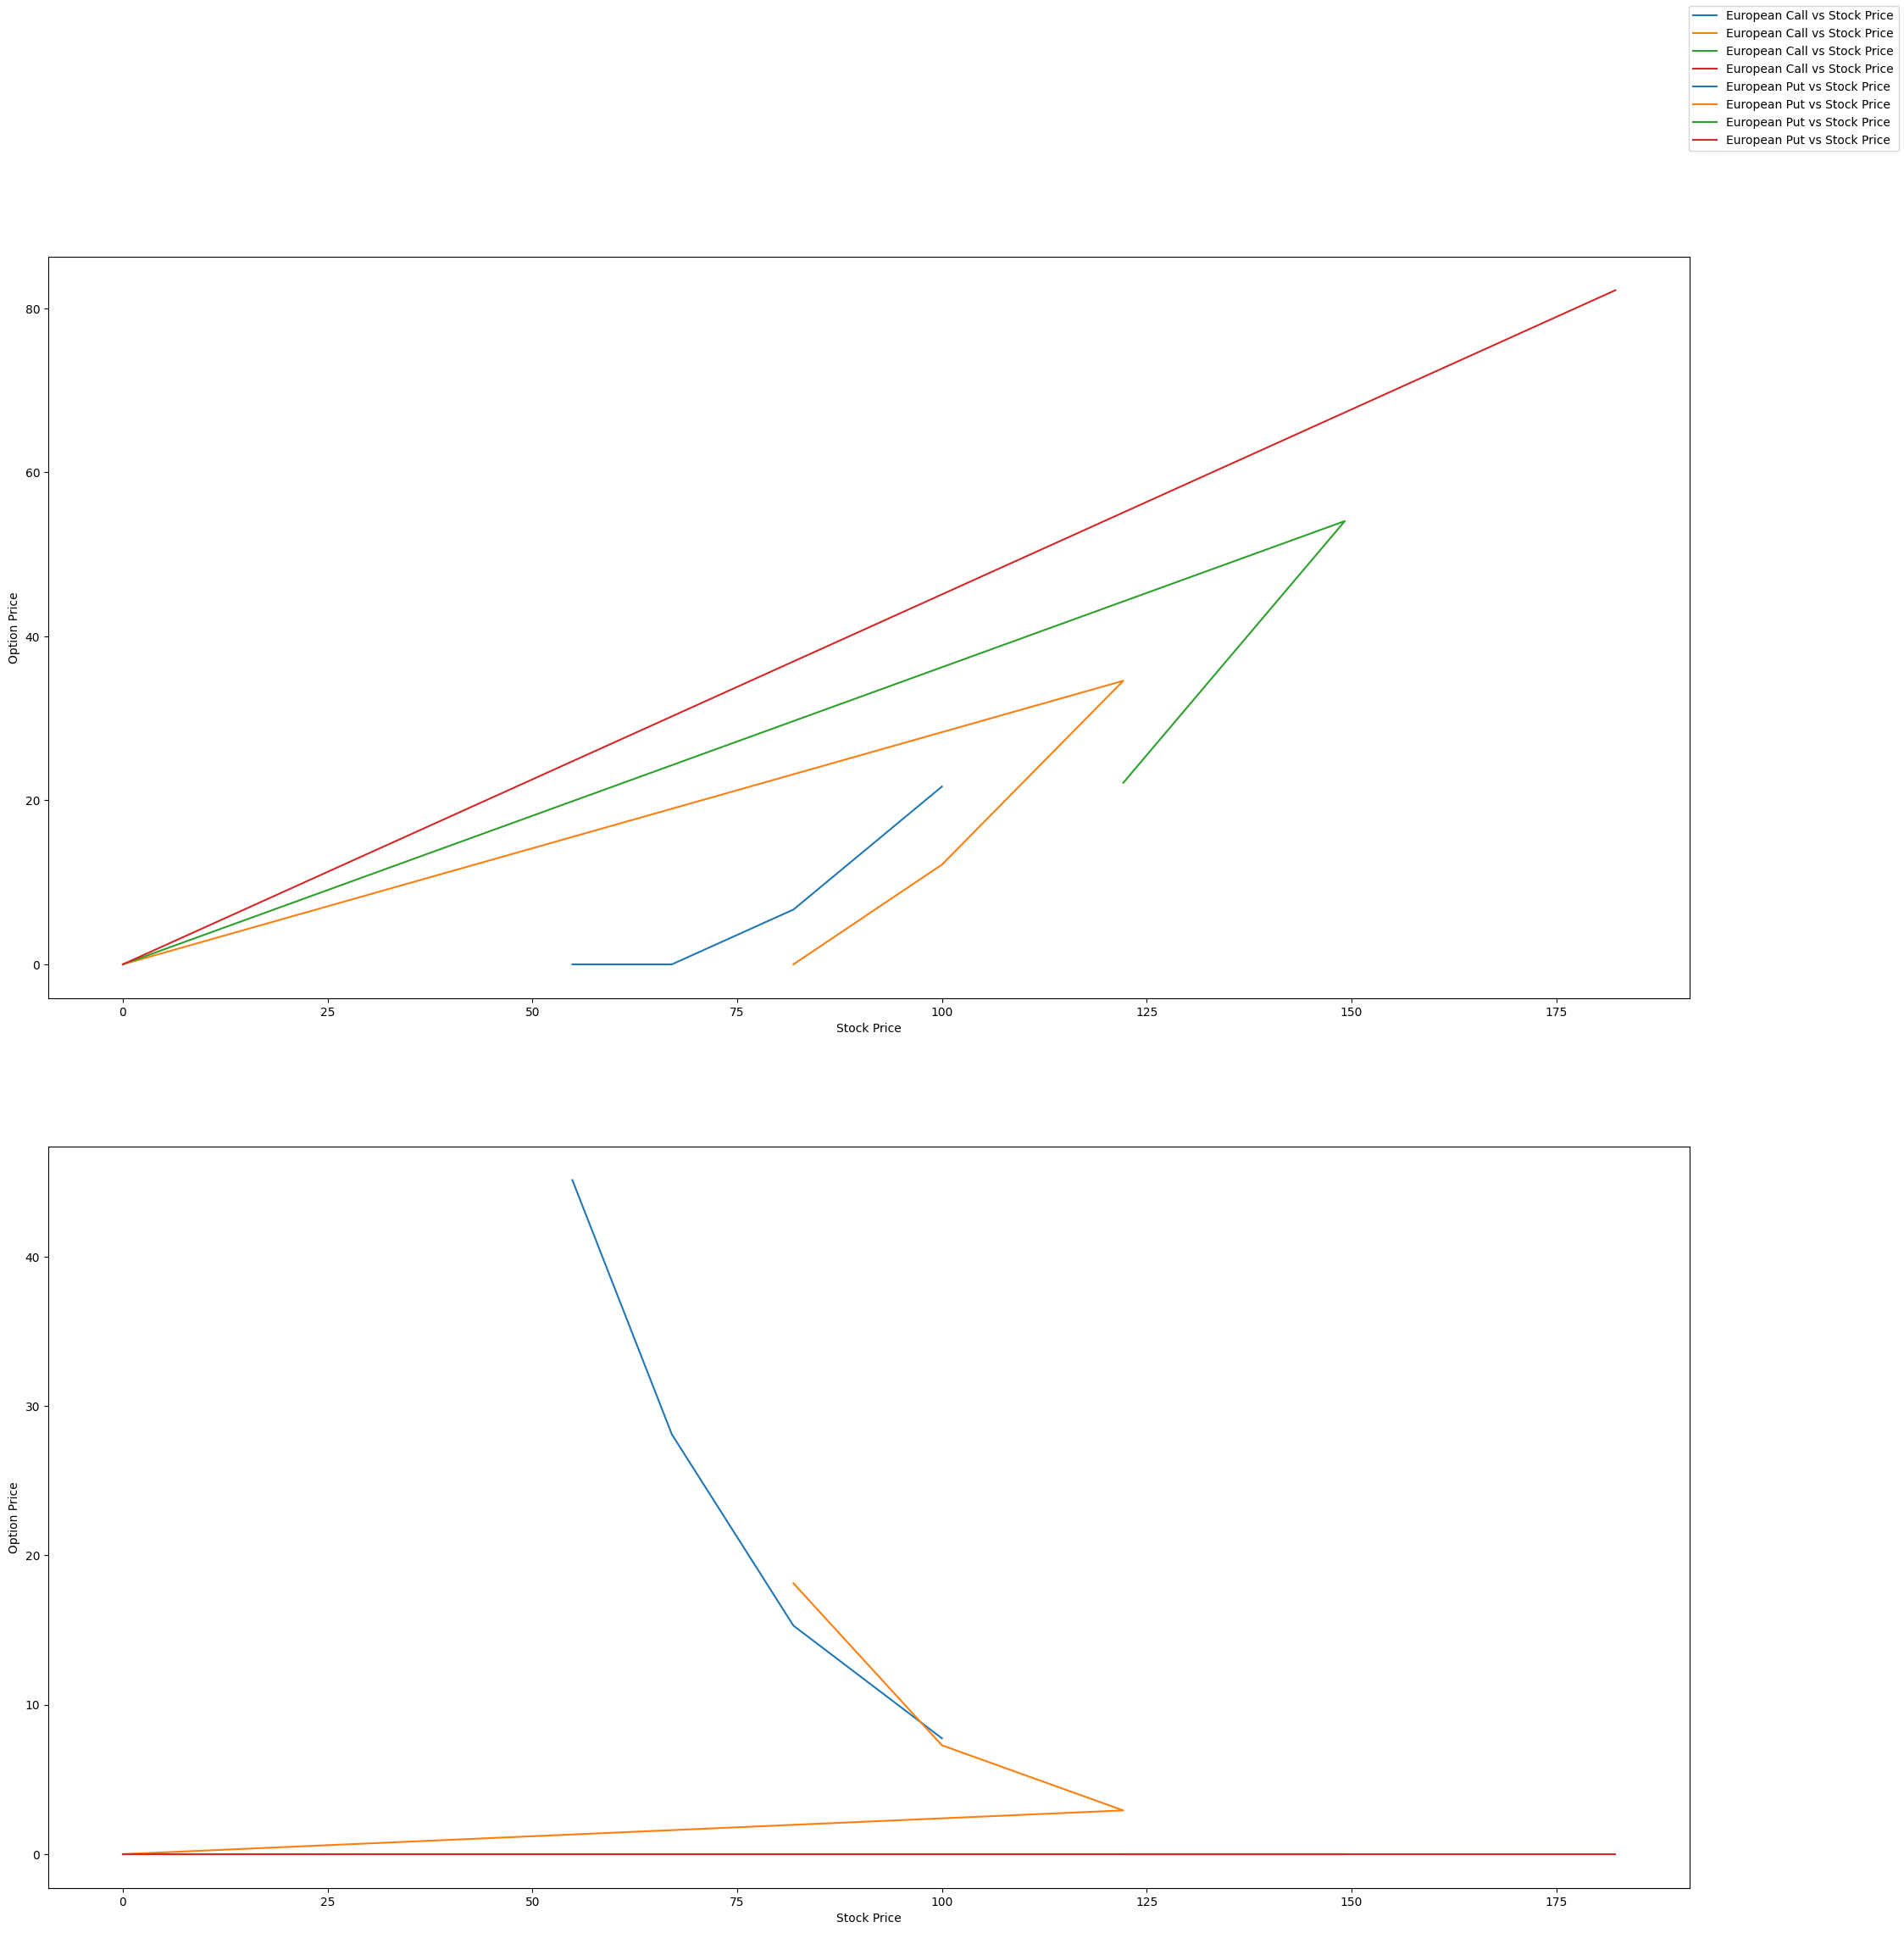

In [ ]:
# Graphing European and American Option Prices vs Stock Price
# European Calls and Puts
fig, ax = plt.subplots(2, figsize=(25,25))
ax[0].plot(S_euro_c, C_euro_c, label="European Call vs Stock Price")
ax[1].plot(S_euro_p, C_euro_p, label="European Put vs Stock Price")
for a in ax.flat:
    a.set(xlabel='Stock Price', ylabel='Option Price')
fig.legend()
plt.savefig("euro_opt_vs_s.png")
plt.show()

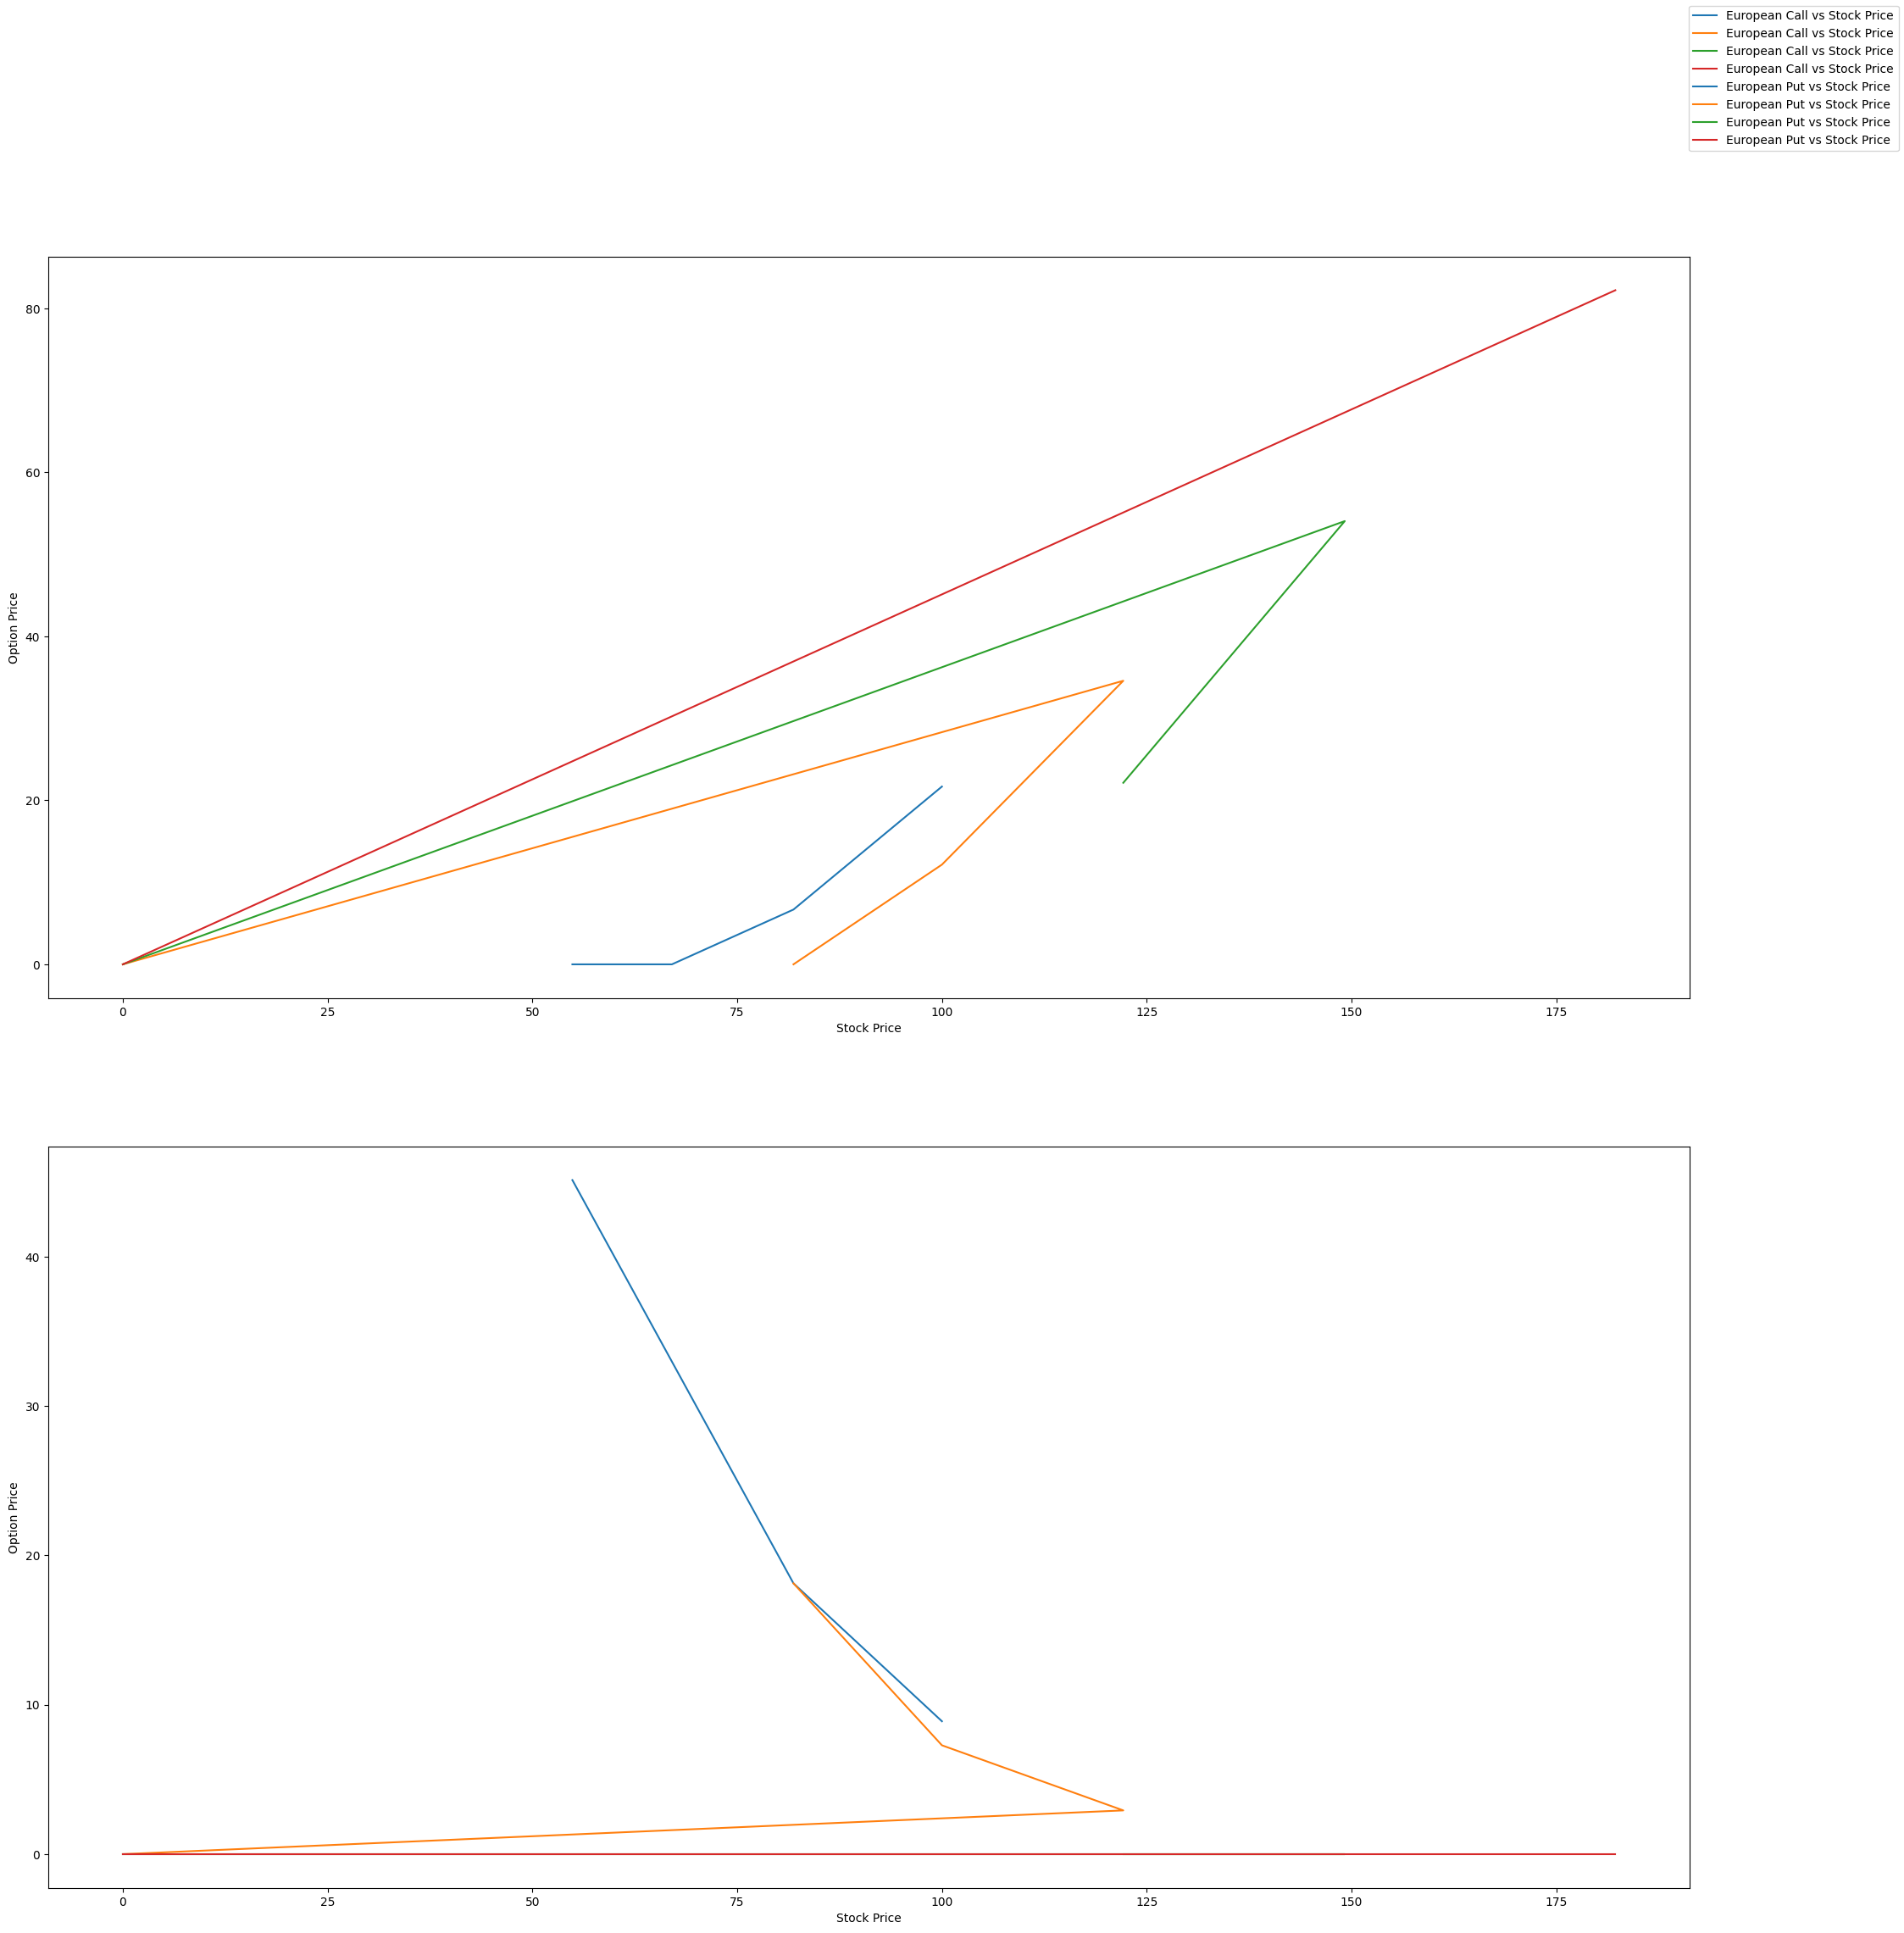

In [ ]:
# American Calls and Puts
fig2, ax2 = plt.subplots(2, figsize=(25,25))
ax2[0].plot(S_american_c, C_american_c, label="European Call vs Stock Price")
ax2[1].plot(S_euro_p, C_american_p, label="European Put vs Stock Price")
for a in ax2.flat:
    a.set(xlabel='Stock Price', ylabel='Option Price')
fig2.legend()
plt.savefig("american_opt_vs_s.png")
plt.show()

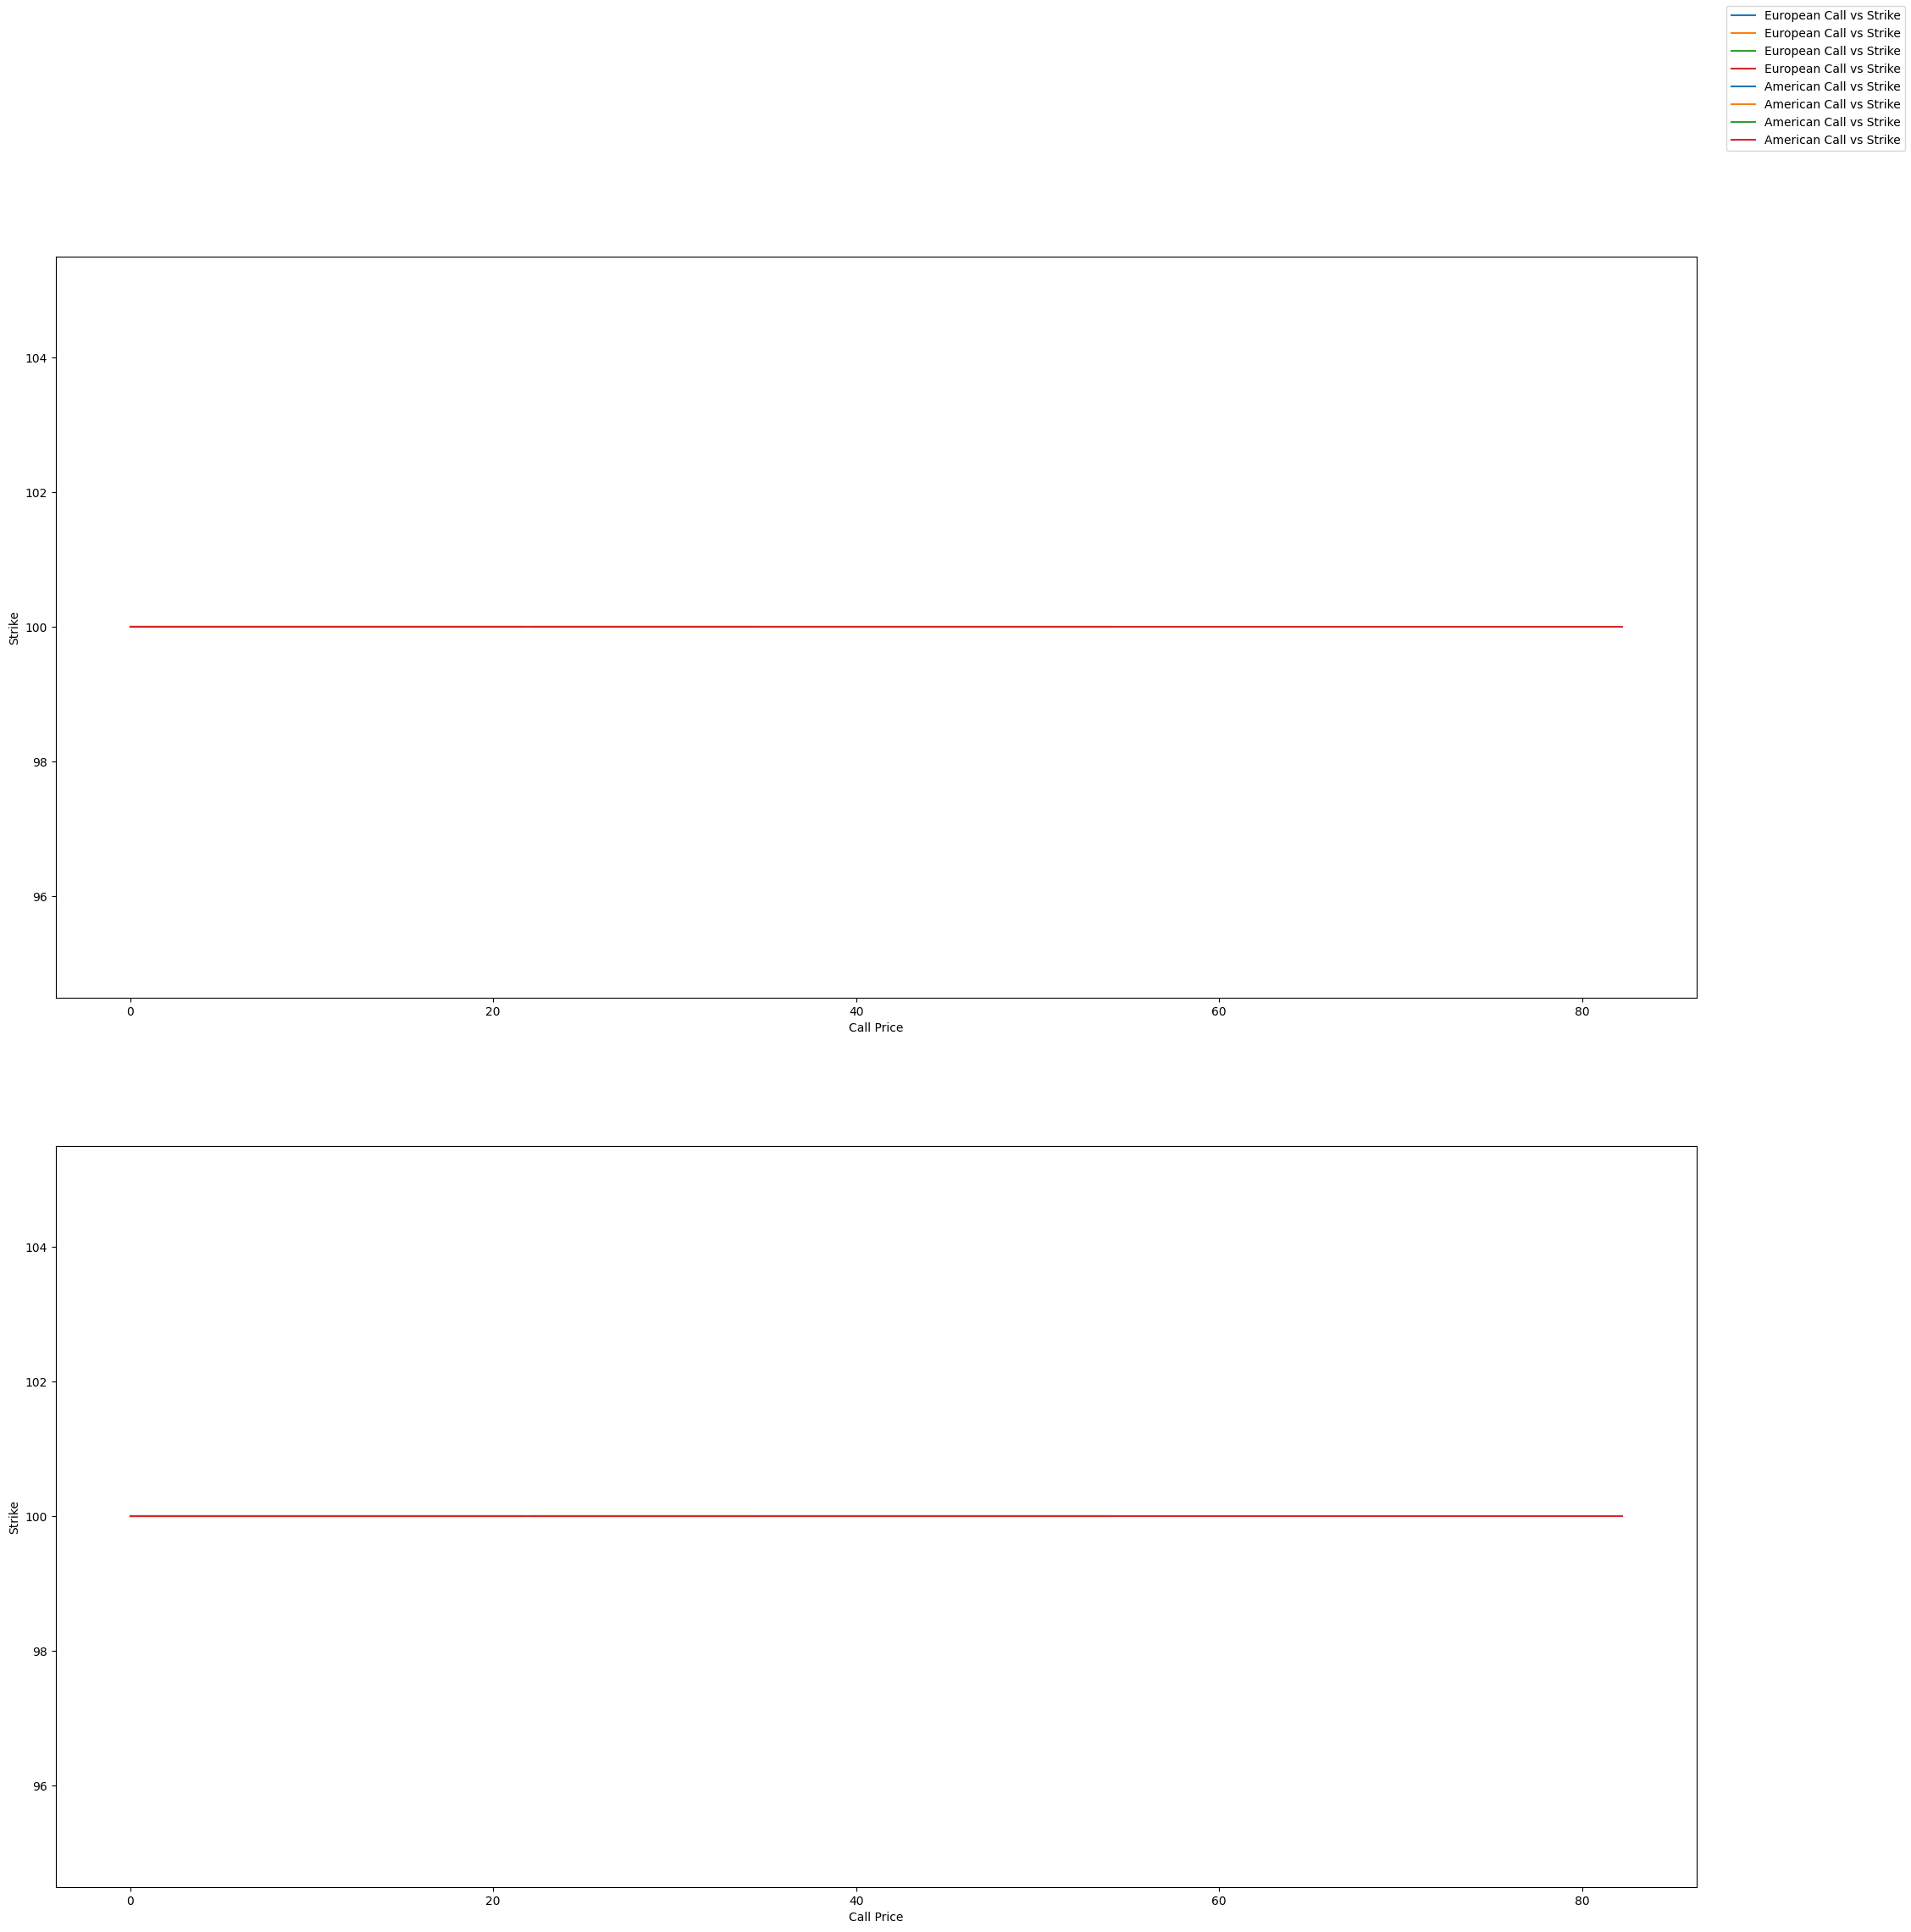

In [ ]:
K = 100
K_arr = K*np.ones(len(S_euro_c))
# European and American Calls vs Strike
fig3, ax3 = plt.subplots(2, figsize=(25,25))
ax3[0].plot(C_euro_c, K_arr, label="European Call vs Strike")
ax3[1].plot(C_american_c, K_arr, label="American Call vs Strike")
for a in ax3.flat:
    a.set(xlabel='Call Price', ylabel='Strike')
fig3.legend()
plt.savefig("euroam_delta_call_vs_strike.png")
plt.show()

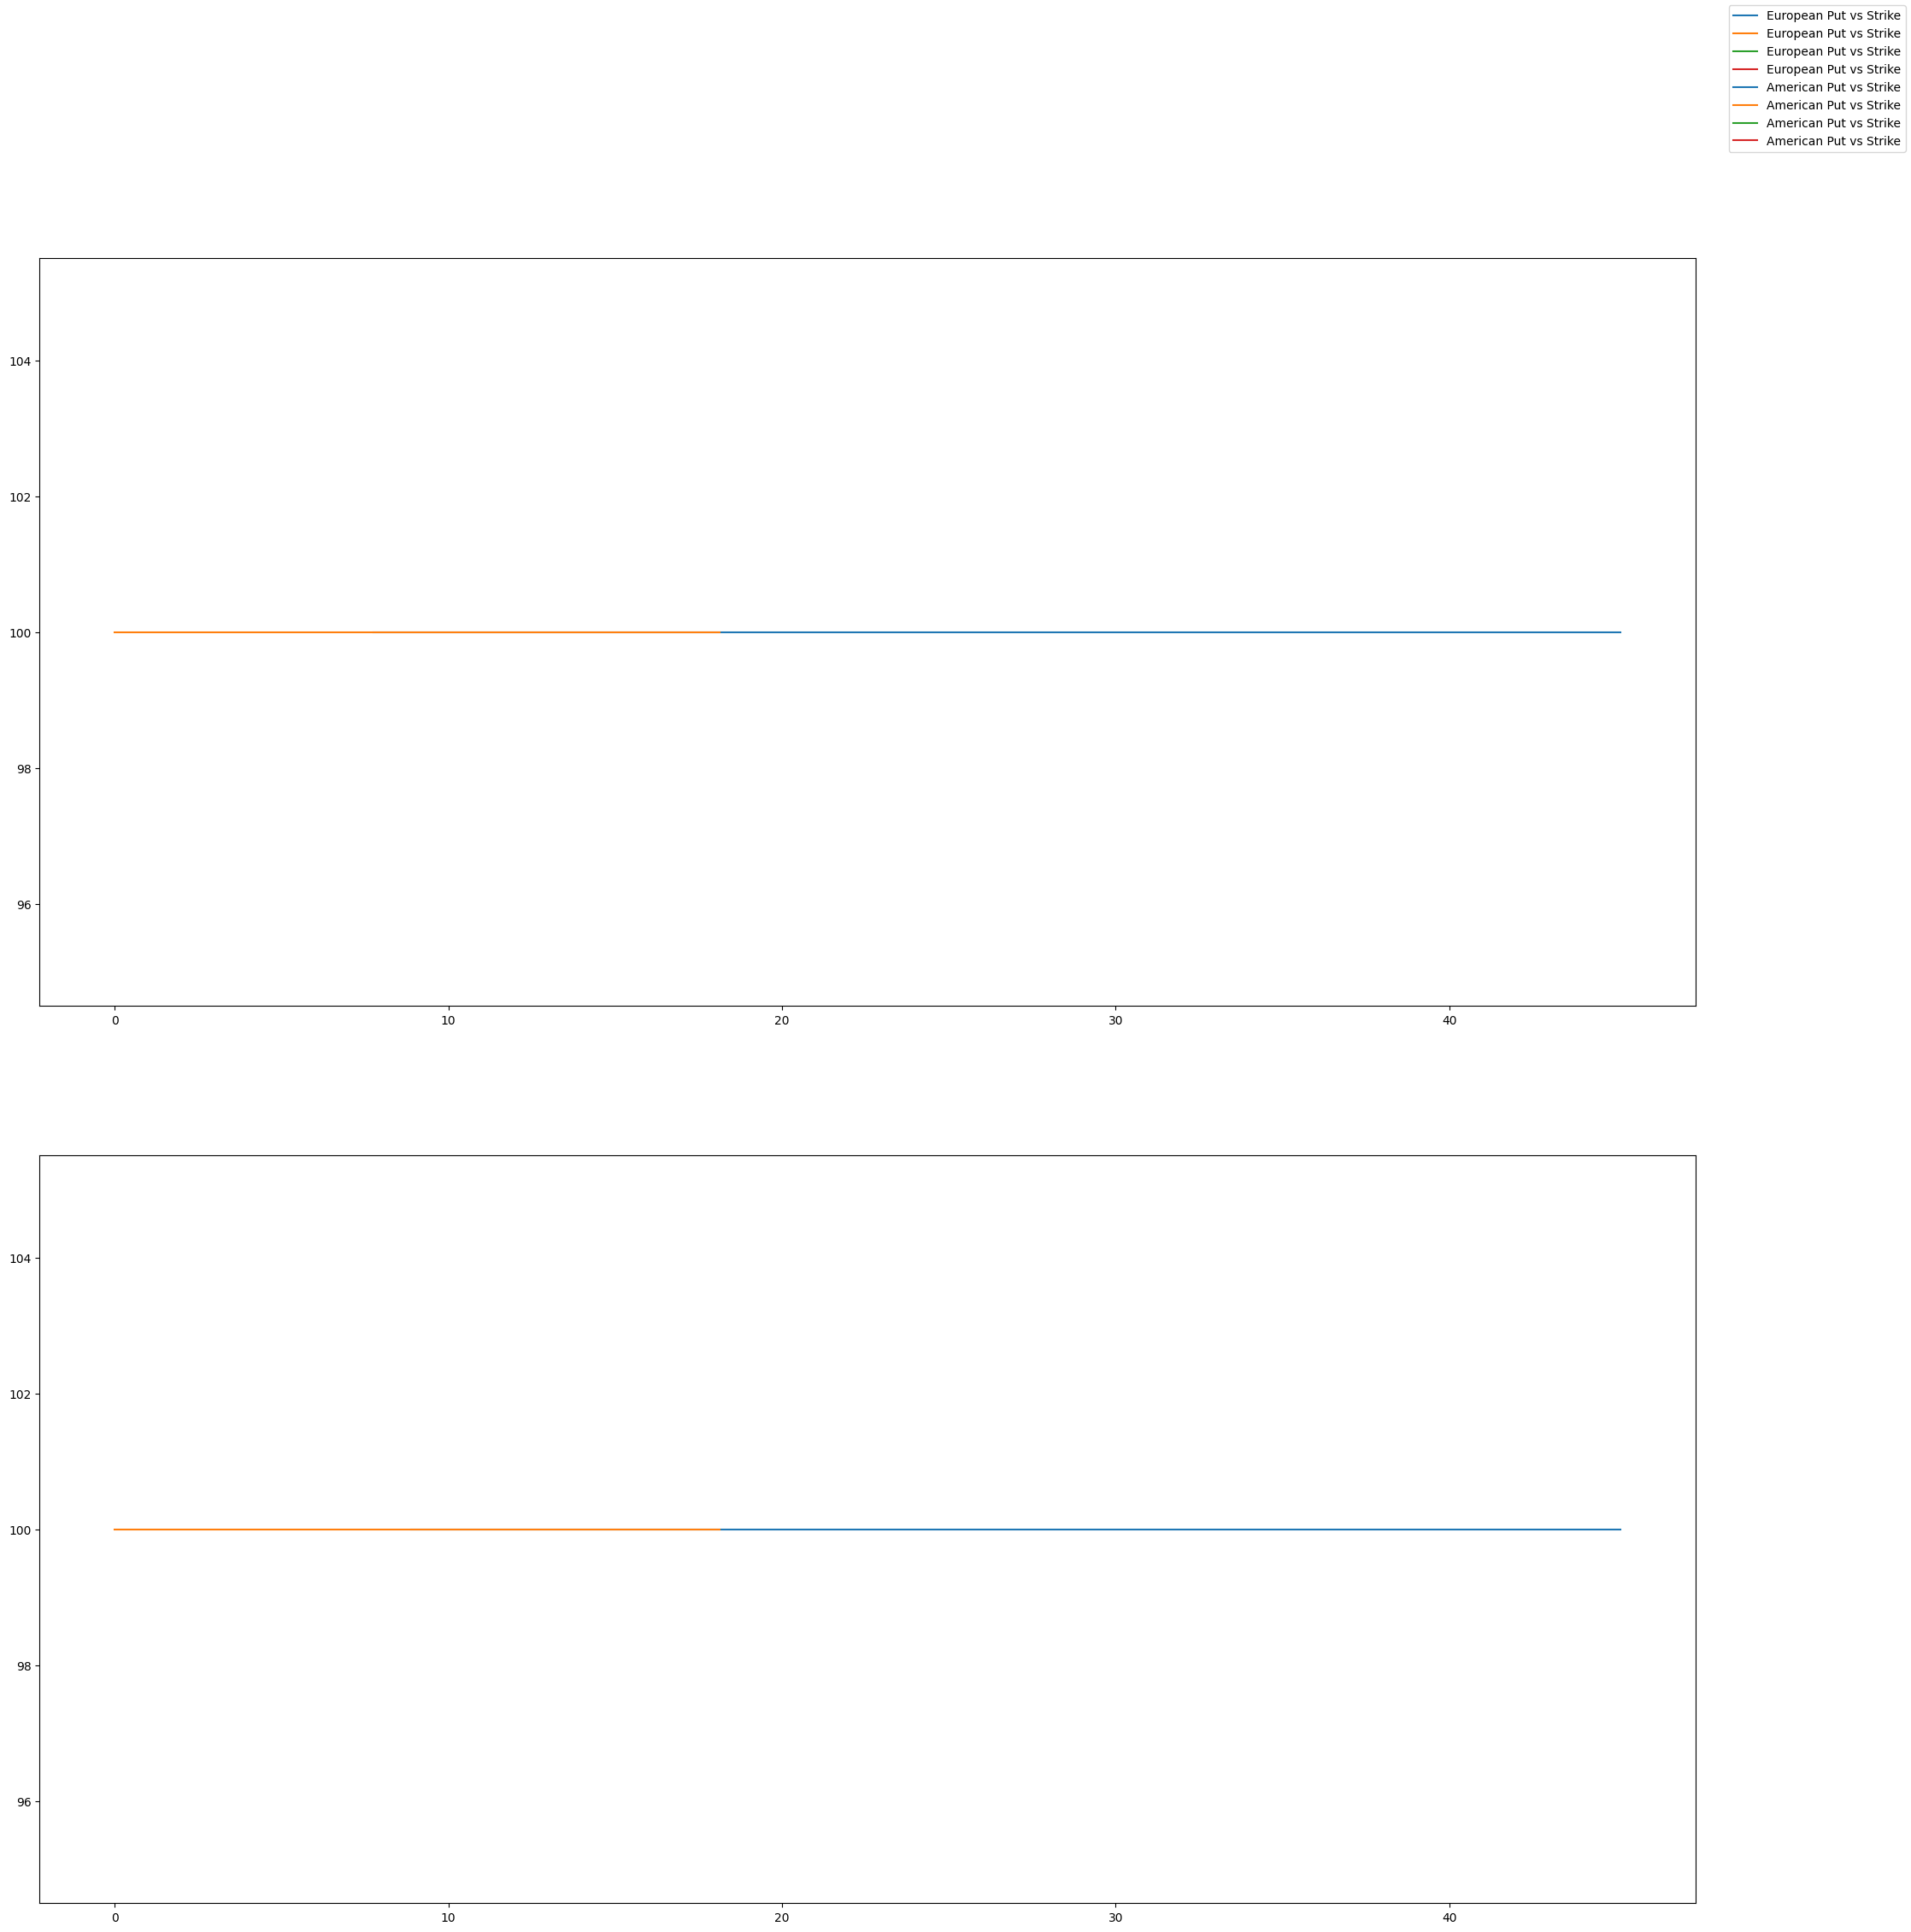

In [ ]:
# European and American Puts vs Strike
fig4, ax4 = plt.subplots(2, figsize=(25,25))
ax4[0].plot(C_euro_p, K_arr, label="European Put vs Strike")
ax4[1].plot(C_american_p, K_arr, label="American Put vs Strike")
for a in ax3.flat:
    a.set(xlabel='Put Price', ylabel='Strike')
fig4.legend()
plt.savefig("euroam_delta_put_vs_strike.png")
plt.show()

# **Step 3**

**Question 23: Put-Call Parity for European Options (Deep OTM to Deep ITM)**

In order from deep OTM to deep ITM, we have for European options: LHS = 26.81 + 90exp(-0.05*2) = 108.24 != RHS = 100 + 4.28 = 104.28; LHS = 23.46 + 95exp(-0.05*2) = 109.42 != 100 + 5.22 = 105.22; LHS = 20.10 + 100exp(-0.05*2) = 110.58 != 100 + 6.17 = 106.17; LHS = 18.30 + 105exp(-0.05*2) = 113.31 != 100 + 8.67 = 108.67 and LHS = 16.50 + 110exp(-0.05*2) = 116.03 != 100 + 11.17 = 111.17. In all cases, put-call parity does not hold. This is likely due to the gradually increasing discount on the strike with time to maturity, which creates arbitrage opportunities.

**Question 24**

The prices obtained for the American call and put options were identical to that of the European options. Assuming no early exercise of any of the options, the same calculations performed in question (23) apply to the American options with no change in value. Put-call parity does not hold in all cases due to the non-linear increase in the discount on the strike with time steps, which creates arbitrage opportunities for the seller.

**Question 25**

In this question, we describe the potential trajectories of, and price a European put option using a 3-step binomial tree. The option is based on an underlying stock that has an initial price $S_0=180$, a strike price of $K=182$, a risk-free rate of $r=0.02$, a volatility of $\sigma = 0.25$, and has 6 months to maturity, i.e. $T=6$. In this case, as we are using 3 periods for our binomial tree, the number of steps $N=3$.

The calculations for the put price at each step of the binomial tree are as follows:

$\text{Risk-neutral probability}\ p = \frac{e^{rdt}-d}{u-d} = \frac{e^{0.02(6/3)}-e^{0.25\sqrt{6/3}}}{e^{0.25\sqrt{6/3}}-e^{-0.25\sqrt{6/3}}} = 0.469$

$N=0: p_1 = 0.469(e^{0.25\sqrt{6/3}}*2) + 0.531(e^{-0.25\sqrt{6/3}}*2)=1.98$

$N=1: p_1 = e^{-0.02(2)}[0.469(e^{0.25\sqrt{6/3}}*0) + 0.531(e^{-0.25\sqrt{6/3}}*55.61)]=19.92$

$N=2: p_1 = e^{-0.02(4)}[0.469(e^{0.25\sqrt{6/3}}*0) + 0.531(e^{-0.25\sqrt{6/3}}*93.25)]=32.10$

$N=3: p_1 = e^{-0.02(6)}[0.469(e^{0.25\sqrt{6/3}}*0) + 0.531(e^{-0.25\sqrt{6/3}}*119.68)]=39.58$

We pick the path {d, d} in the tree. Having calculated the payoffs for upward and downward movements for the 3 steps above, we substitute their values into the Delta expressions here. We calculate the deltas as follows:

$\Delta_0 = \frac{c_1^u - c_1^d}{S_u - S_d} = \frac{0-55.61}{256.34-126.39} = -0.428$

$\Delta_1 = \frac{c_2^u - c_2^d}{S_u - S_d} = \frac{0-93.25}{179.99-88.75} = -1.02$

$\Delta_2 = \frac{c_3^u - c_3^d}{S_u - S_d} = \frac{0-119.68}{126.39-62.32} = -1.87$

The investor would sell 0.428 shares at step 0, 1.02 - 0.428 = 0.574 shares at step 1 and 1.87 - 1.02 = 0.85 shares at step 2. We also present the portfolio table for the path calculated below:

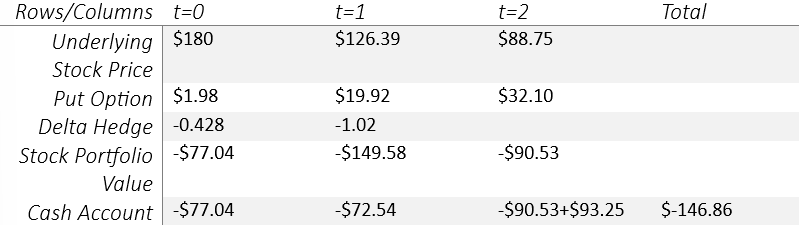


**Question 26**

We now price an American put option with the same starting data as question (25).

In [ ]:
S_0 = 180
r = 0.02
sigma = 0.25
T = 6
K = 182
N = 25
dt = T/N
u, d = np.exp(sigma*np.sqrt(dt)), np.exp(-sigma*np.sqrt(dt))
price_american_p_26, C_american_p_26, S_american_p_26, delta_american_p_26 = american_option(S_0, K, T, r, u, d, N, "P")
print(delta_american_p_26)

[[-3.57075976e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-4.55323498e-01 -2.76717807e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-5.69275594e-01 -3.62120316e-01 -2.06865773e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.0

The following displays the evolution in the cash account for the path where the priec always moves upward:

In [ ]:
cash_acc_l = []
cash_acc = 0
for i in range(len(delta_american_p_26)):
  if i == 0:
    cash_acc += delta_american_p_26[i][0]*S_american_p_26[i]
  else:
    cash_acc += (delta_american_p_26[i][0] - delta_american_p_26[i][0])*S_american_p_26[i]
    if i == len(delta_american_p_26)-1:
      cash_acc -= S_american_p_26[i] - C_american_p_26[i]
cash_acc_l.append(cash_acc)
print(f"Cash Account Balance: {cash_acc_l}")

Cash Account Balance: [array([   98.68300524,   157.67109099,   150.91845332,   142.29157972,
         131.27026452,   117.18991581,    99.20148009,    76.22024388,
          46.86042485,     9.35160827,   -38.56801004,   -99.78801184,
        -168.43129783,  -229.9601022 ,  -293.78693668,  -375.32929991,
        -479.50424536,  -612.59358481,  -782.62268539,  -999.84440396,
       -1277.35734065, -1631.89569221, -2084.8383342 , -2663.49797999,
       -3402.76815378,     0.        ])]


The evolution in the cash account when selling the American put is more volatile than that when selling the European put as a result of the difference in option price assignment, which is pegged to the higher of two values (current value vs the difference between the current stock price and strike price).

Finally, below we display the price of the American put option:

In [ ]:
print(f"Price of American Put Option: {price_american_p_26}")

Price of American Put Option: 35.52448836010561


**Question 27: Calculating the Price of an Asian Option**

Here we opt to use Monte Carlo simulations to calculate the Asian option price.

In [ ]:
# Let's use Monte Carlo to calculate the payoff of the Asian option
def asian_option(S_ini, K, T, r, sigma, N, M):
  dt = T/N
  u = np.exp(sigma * np.sqrt(dt))
  d = np.exp(-sigma * np.sqrt(dt))
  p = (np.exp(r*dt) - d)/(u - d)
  Asian = np.zeros([M])
  S = np.zeros([M, N+1])
  S[:,0] = S_ini

  for j in range(0, M):
    random = np.random.binomial(1, p, N+1)
    Total = S_ini
    for i in range(1, N+1):
      if random[i] == 1:
        S[j, i] = S[j, i-1] * u
        Total = Total + S[j, i]
      else:
        S[j, i] = S[j, i-1] * d
        Total = Total + S[j, i]

    Asian[j] = np.exp(-r*T)*max(Total / (N+1) - K, 0)
  return Asian, S

In [ ]:
# To increase the likelihood of settling on a convergence, we plot with a large number of simulations (M-value). Here we use M = 10000.
# We then use the mean value as the final result
asian, s = asian_option(S_0, K, T, r, sigma, N, 10000)
print(np.mean(asian))

27.89143042411858


We obtain a price of $27.44 for the Asian option. This is lower than the computed price for the American put.

# **Table of Values for Option Prices**

In [ ]:
options_df = pd.DataFrame({
    "Type": ["ATM Call", "ATM Put", "ATM Call", "ATM Put"],
    "Exer": ["Eur", "Eur", "Amer", "Amer"],
    "GWP1 Method": ["Binomial", "Binomial", "Binomial", "Binomial"],
    "GWP1 Price": [price_euro_c, price_euro_p, price_american_c, price_american_p]
})
options_df.style \
  .format(precision=3, thousands=".", decimal=",") \
  .format_index(str.upper, axis=1) \
  .relabel_index(["5", "5", "8", "8"], axis=0)

,TYPE,EXER,GWP1 METHOD,GWP1 PRICE
5,ATM Call,Eur,Binomial,"21,683"
5,ATM Put,Eur,Binomial,"7,754"
8,ATM Call,Amer,Binomial,"21,683"
8,ATM Put,Amer,Binomial,"8,894"


# **References**

WorldQuant University. (2024, July 23). MScFE620: Derivative Pricing (Modules 1-3).